# Exportación de modelo de ML

In [197]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer, OrdinalEncoder
from sklearn.compose import ColumnTransformer

## Conjunto de datos utilizado

El conjunto de datos a utilizar es el **Student Performance Dataset** de Kaggle, encontrado en este vínculo: [https://www.kaggle.com/datasets/amar5693/student-performance-dataset](https://www.kaggle.com/datasets/amar5693/student-performance-dataset)

In [198]:
data = pd.read_csv('data.csv')
data

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,exercise_minutes,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,focus_index,burnout_level,productivity_score,exam_score
0,1,18,Other,High School,7.64,1.56,2.20,3.05,2.19,6.52,...,81,38,1,0,Good,10,43.05,31.77,73.65,50.16
1,2,18,Other,High School,2.21,2.22,2.10,1.65,2.55,5.97,...,111,339,0,0,Good,3,15.92,37.00,13.70,1.00
2,3,22,Male,High School,3.45,0.00,0.29,1.34,2.08,8.39,...,68,266,0,1,Good,8,27.39,34.37,45.15,18.30
3,4,17,Other,High School,5.75,2.08,3.01,2.27,2.20,6.31,...,113,480,1,1,Poor,3,22.31,77.31,20.92,9.37
4,5,19,Other,High School,6.83,1.72,3.33,2.65,0.70,8.01,...,121,24,1,0,Good,8,38.11,39.53,59.23,27.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,20,Other,Undergraduate,3.93,1.42,0.54,2.58,2.62,9.30,...,113,496,0,0,Good,9,35.55,33.24,48.83,22.51
4996,4997,24,Male,High School,4.00,0.00,3.00,4.45,2.47,6.42,...,146,411,0,1,Poor,5,16.87,59.07,23.32,2.00
4997,4998,22,Male,Undergraduate,5.63,2.52,2.89,3.58,1.07,6.65,...,123,306,0,1,Good,7,23.85,47.72,41.09,27.89
4998,4999,17,Male,Undergraduate,3.58,2.83,1.53,5.88,1.28,7.36,...,54,304,1,1,Good,4,13.04,58.90,12.62,3.63


In [199]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5000 non-null   int64  
 1   age                   5000 non-null   int64  
 2   gender                5000 non-null   object 
 3   academic_level        5000 non-null   object 
 4   study_hours           5000 non-null   float64
 5   self_study_hours      5000 non-null   float64
 6   online_classes_hours  5000 non-null   float64
 7   social_media_hours    5000 non-null   float64
 8   gaming_hours          5000 non-null   float64
 9   sleep_hours           5000 non-null   float64
 10  screen_time_hours     5000 non-null   float64
 11  exercise_minutes      5000 non-null   int64  
 12  caffeine_intake_mg    5000 non-null   int64  
 13  part_time_job         5000 non-null   int64  
 14  upcoming_deadline     5000 non-null   int64  
 15  internet_quality     

In [200]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,5000.0,2500.500000,1443.520003,1.0,1250.7500,2500.50,3750.2500,5000.00
age,5000.0,20.520400,2.870406,16.0,18.0000,20.00,23.0000,25.00
study_hours,5000.0,4.539594,1.821665,0.0,3.2500,4.53,5.7600,11.84
self_study_hours,5000.0,2.478734,1.177990,0.0,1.6600,2.48,3.2900,7.41
online_classes_hours,5000.0,2.011984,0.983906,0.0,1.3200,2.01,2.6900,6.00
social_media_hours,5000.0,2.998086,1.467949,0.0,1.9900,2.98,4.0300,8.28
gaming_hours,5000.0,1.564514,1.110807,0.0,0.6700,1.49,2.3400,5.64
sleep_hours,5000.0,7.016492,1.163692,4.0,6.2375,7.01,7.8100,10.00
screen_time_hours,5000.0,6.979588,2.486214,1.0,5.2800,6.95,8.7100,15.30
exercise_minutes,5000.0,74.535600,42.932293,0.0,37.0000,75.00,112.0000,149.00


## Visualización de datos

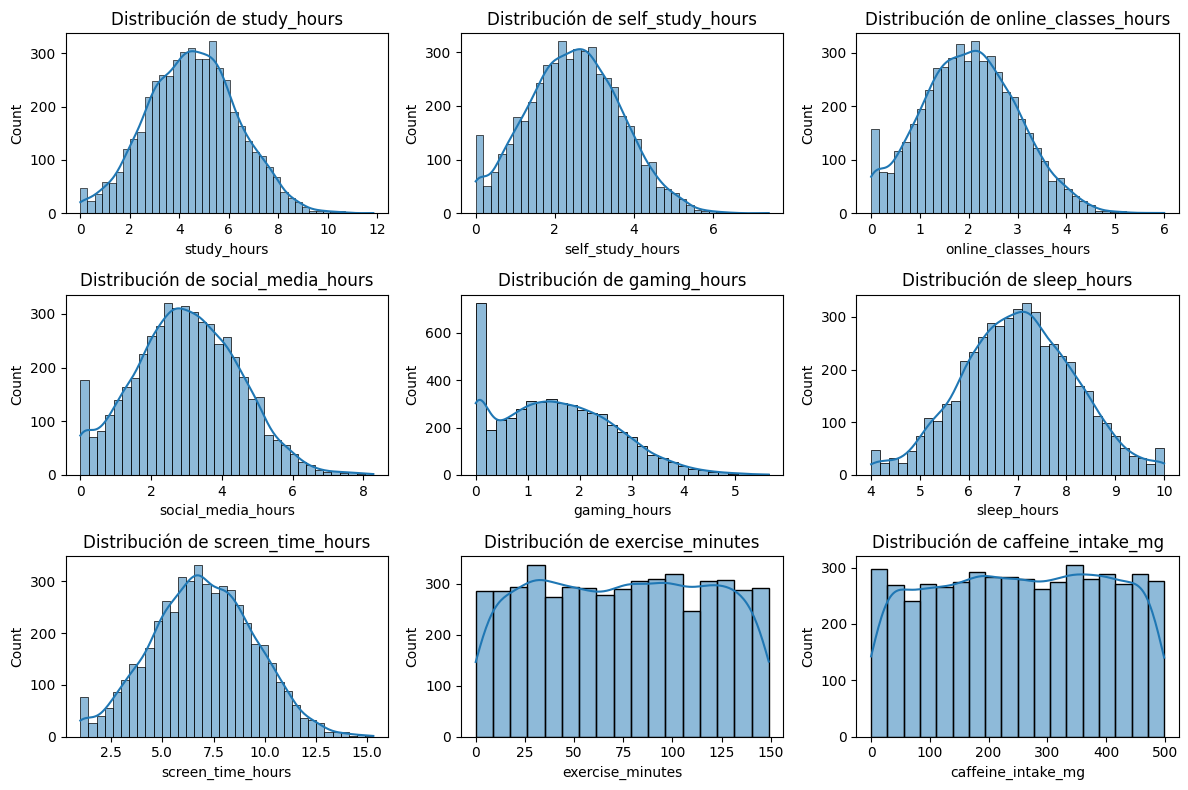

In [201]:
numerical_cols = data.select_dtypes(include=['int64', 'float64']).columns
numerical_colsVis = numerical_cols.drop(['student_id', 'age'])

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(12, 8))

for ax, col in zip(axs.ravel(), numerical_colsVis):
    sns.histplot(data[col], kde=True, ax=ax)
    ax.set_title(f'Distribución de {col}')

fig.tight_layout()

## Matriz de correlación

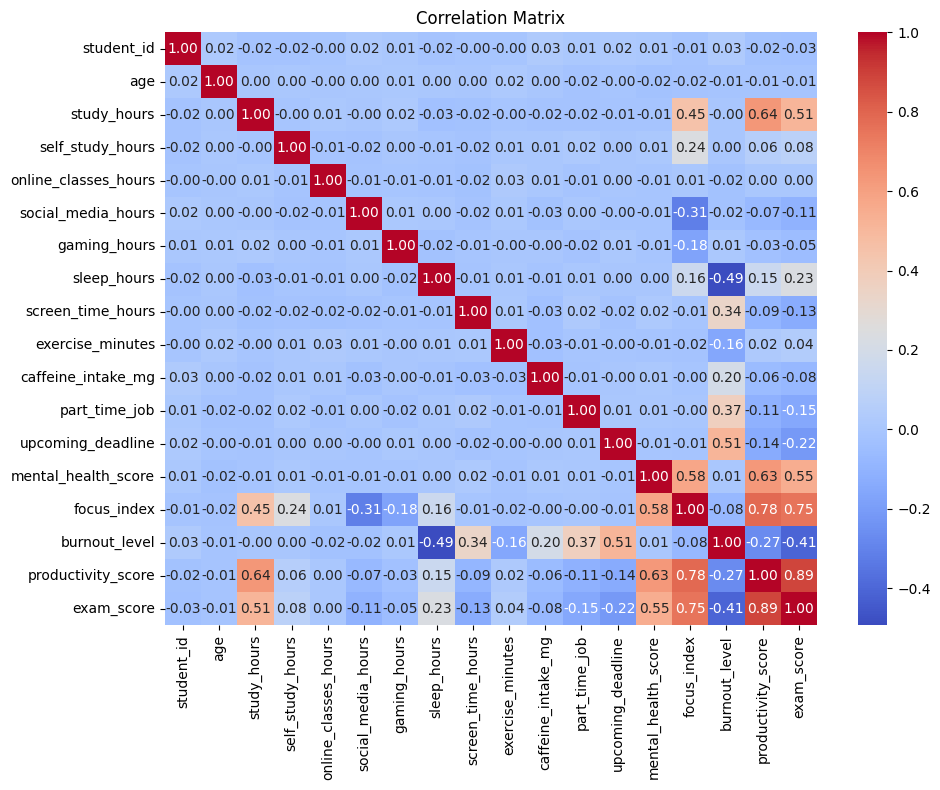

In [202]:
corr_matrix = data[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()

## Checar por valores vacíos

<Axes: >

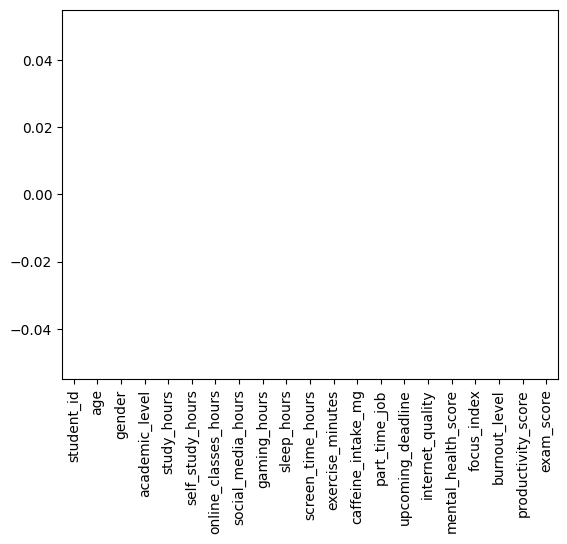

In [203]:
missing_counts = data.isnull().sum()
missing_counts.plot(kind='bar')

Como podemos ver, no hay datos faltantes.

## Pre-procesamiento de datos

Nos enfocaremos únicamente en las condiciones personales del alumno, por lo cual excluiremos la columna de 'internet_quality'.

In [204]:
numerical_cols

Index(['student_id', 'age', 'study_hours', 'self_study_hours',
       'online_classes_hours', 'social_media_hours', 'gaming_hours',
       'sleep_hours', 'screen_time_hours', 'exercise_minutes',
       'caffeine_intake_mg', 'part_time_job', 'upcoming_deadline',
       'mental_health_score', 'focus_index', 'burnout_level',
       'productivity_score', 'exam_score'],
      dtype='object')

In [205]:
preprocessing_pipeline = make_pipeline(
    ColumnTransformer(
        transformers=[
            ('ordinal_gender', OneHotEncoder(handle_unknown='ignore', drop='first'), ['gender']),
            ('ordinal_academic_level', OrdinalEncoder(categories=[['High School', 'Undergraduate', 'Graduate', 'PostGraduate']], handle_unknown='use_encoded_value', unknown_value=-1), ['academic_level']),
            ('drop_internet_quality', 'drop', ['internet_quality'])
        ]
        , remainder='passthrough'
)
)

In [206]:
categorical_cols = data.select_dtypes(include=['object']).columns
# Exclude 'exam_score' from the numerical columns to prevent data leakage
features_to_use = [col for col in numerical_cols if col != 'exam_score'] + list(categorical_cols)
x = data[features_to_use]
y = data['exam_score']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [207]:
x_train_processed = preprocessing_pipeline.fit_transform(x_train, y_train)
x_test_processed = preprocessing_pipeline.transform(x_test)

In [208]:
regression_model = make_pipeline(
    preprocessing_pipeline,
    LinearRegression()
)

In [209]:
regression_model

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('ordinal_gender',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'),
                                                                   ['gender']),
                                                                  ('ordinal_academic_level',
                                                                   OrdinalEncoder(categories=[['High '
                                                                                               'School',
                                                                                               'Undergraduate',
                                                                                               'Graduate',
                                                                                               'PostGraduate']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['academic_level']),
                                                                  ('drop_internet_quality',
                                                                   'drop',
                                                                   ['internet_quality'])]))])),
                ('linearregression', LinearRegression())])

In [210]:
regression_model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('columntransformer',
                                  ColumnTransformer(remainder='passthrough',
                                                    transformers=[('ordinal_gender',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'),
                                                                   ['gender']),
                                                                  ('ordinal_academic_level',
                                                                   OrdinalEncoder(categories=[['High '
                                                                                               'School',
                                                                                               'Undergraduate',
                                                                                               'Graduate',
                                                                                               'PostGraduate']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1),
                                                                   ['academic_level']),
                                                                  ('drop_internet_quality',
                                                                   'drop',
                                                                   ['internet_quality'])]))])),
                ('linearregression', LinearRegression())])

In [211]:
y_test_pred = regression_model.predict(x_test)
y_test_pred

array([ 2.75717822e+01,  1.10821809e+01,  1.68807834e+01,  2.97160055e+01,
        1.95145101e+01,  1.54030053e+01,  2.05889219e+01,  2.38486178e+01,
        3.71673555e+01,  2.85772358e+00,  6.45876547e+00,  2.37075159e+01,
        3.23604464e+01,  2.88753195e+01,  2.95718551e+01,  1.95453765e+01,
        2.40589542e+01, -2.82584865e-01,  2.01647741e+01,  3.68011799e+01,
        2.03110207e+01,  7.25994957e+00,  3.50252561e+01,  1.79312606e+01,
        3.13938237e+01,  2.84384765e+01,  1.70032757e+01,  2.10467853e+01,
        1.56768051e+00,  2.51039425e+01,  2.09326177e+01, -4.57637945e+00,
        2.45212491e+01,  2.30750769e+01, -3.83656685e+00,  1.39061780e+00,
        3.23583171e+01,  2.48114307e+01,  2.11673908e+01,  3.74318955e+01,
        1.20158930e+01,  3.10814437e+01,  1.34138329e+01,  3.39913708e+01,
        1.75853037e+01,  2.16294739e+01, -1.88537609e+00,  2.13645240e+01,
        2.18489073e+01,  1.17011255e+01,  2.42547854e+00,  1.13238525e+01,
        2.00414317e+01, -

In [212]:
x_test['pred_exam_score'] = y_test_pred
x_test['real_exam_score'] = y_test.values
x_test

,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,exercise_minutes,...,upcoming_deadline,mental_health_score,focus_index,burnout_level,productivity_score,gender,academic_level,internet_quality,pred_exam_score,real_exam_score
1501,1502,21,1.69,1.27,2.03,3.01,0.93,7.76,9.30,141,...,1,10,33.02,34.29,49.20,Female,Postgraduate,Good,27.571782,27.21
2586,2587,22,5.83,1.85,1.52,3.00,0.88,6.89,13.89,41,...,1,6,30.61,76.88,32.73,Other,High School,Average,11.082181,4.22
2653,2654,23,2.97,0.67,2.80,1.72,0.75,5.00,7.78,10,...,0,7,34.04,60.70,34.98,Female,High School,Good,16.880783,12.14
1055,1056,20,5.06,1.40,2.57,3.23,1.72,7.57,7.29,146,...,1,10,30.69,49.63,61.26,Male,High School,Good,29.716005,32.94
705,706,19,4.36,2.25,1.19,0.24,1.89,6.49,10.59,100,...,0,6,32.55,40.06,33.99,Female,Undergraduate,Poor,19.514510,22.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4711,4712,23,5.58,2.58,1.56,4.78,3.46,8.01,9.64,84,...,1,7,34.34,63.85,48.35,Male,Undergraduate,Poor,22.053695,22.75
2313,2314,24,4.51,4.56,4.21,2.44,2.20,7.05,10.97,42,...,0,5,34.82,49.19,38.50,Other,Undergraduate,Good,19.968386,20.66
3214,3215,17,5.73,1.03,2.08,2.79,0.86,8.15,10.37,9,...,0,7,42.98,30.16,66.56,Other,Postgraduate,Poor,38.945235,33.85
2732,2733,21,4.91,1.87,2.53,0.04,2.11,5.49,6.41,1,...,0,9,44.49,52.79,54.11,Female,High School,Good,29.934187,27.35


## Evaluación del modelo

In [213]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [214]:
def evaluate_model(model, x, y):
  y_pred = model.predict(x)
  mse = mean_squared_error(y, y_pred)
  mae = mean_absolute_error(y, y_pred)
  r2 = r2_score(y, y_pred)
  rmse = root_mean_squared_error(y, y_pred)

  return {"MSE": mse, "MAE": mae, "R2": r2, "RMSE": rmse}

In [215]:
evaluation_results = evaluate_model(regression_model, x_test, y_test)
evaluation_results

{'MSE': 24.94683039052783,
 'MAE': 3.958068481621794,
 'R2': 0.8169174478090919,
 'RMSE': 4.994680209035192}

# Utilización de joblib para exportar el modelo de regresión lineal

In [216]:
import joblib

In [217]:
# Crear un archivo joblib con el modelo creado
joblib.dump(regression_model, 'regression_model.joblib')

['regression_model.joblib']